## Airline Flight Delay Analysis

#### Objective:

##### Analyze how delays vary by airline, route, airport, and season, and identify the main causes of delays and cancellations.

### 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import plotly.express as px

sns.set_style("whitegrid")

### 2. Load and Inspect the Data

In [2]:
USE_SAMPLE_DATA = True   # change to False later

main_folder = r"C:\Users\lve14\Downloads\FlightData"

if USE_SAMPLE_DATA:
    import numpy as np
    import pandas as pd

    np.random.seed(42)

    n = 3000

    df = pd.DataFrame({
        "FL_DATE": pd.date_range(start="2023-01-01", periods=n, freq="h"),
        "OP_UNIQUE_CARRIER": np.random.choice(["AA", "DL", "UA", "WN", "B6", "NK"], n),
        "ORIGIN": np.random.choice(["DFW", "ATL", "ORD", "LAX", "JFK", "DEN", "SEA", "SFO"], n),
        "DEST": np.random.choice(["DFW", "ATL", "ORD", "LAX", "JFK", "DEN", "SEA", "SFO"], n),
        "ARR_DELAY": np.random.normal(15, 45, n).astype(int),
        "DEP_DELAY": np.random.normal(12, 40, n).astype(int),
        "CANCELLED": np.random.choice([0, 1], n, p=[0.93, 0.07]),
        "DIVERTED": np.random.choice([0, 1], n, p=[0.98, 0.02]),
        "CANCELLATION_CODE": np.random.choice(["A", "B", "C", "D", None], n, p=[0.25, 0.25, 0.25, 0.05, 0.20]),
        "CARRIER_DELAY": np.random.randint(0, 90, n),
        "WEATHER_DELAY": np.random.randint(0, 60, n),
        "NAS_DELAY": np.random.randint(0, 80, n),
        "SECURITY_DELAY": np.random.randint(0, 10, n),
        "LATE_AIRCRAFT_DELAY": np.random.randint(0, 100, n),
        "CRS_DEP_TIME": np.random.randint(0, 2359, n)
    })

else:
    df_list = []

    for root, dirs, files in os.walk(main_folder):
        for file in files:
            if file.lower().endswith(".csv"):
                file_path = os.path.join(root, file)
                temp_df = pd.read_csv(file_path)
                df_list.append(temp_df)

    if len(df_list) == 0:
        raise ValueError("No CSV files found. Check your path.")

    df = pd.concat(df_list, ignore_index=True)

print(df.head())
df.info()
print(df.describe())
print(df.shape)
print(df.isna().sum())

              FL_DATE OP_UNIQUE_CARRIER ORIGIN DEST  ARR_DELAY  DEP_DELAY  \
0 2023-01-01 00:00:00                WN    DFW  JFK         48         23   
1 2023-01-01 01:00:00                B6    JFK  DFW        -38         93   
2 2023-01-01 02:00:00                UA    ATL  DEN         23         34   
3 2023-01-01 03:00:00                B6    SFO  ATL         69         35   
4 2023-01-01 04:00:00                B6    JFK  LAX         36          1   

   CANCELLED  DIVERTED CANCELLATION_CODE  CARRIER_DELAY  WEATHER_DELAY  \
0          0         0               NaN             46             50   
1          0         1                 B             49              1   
2          0         0                 A             59             47   
3          0         0                 C             61             11   
4          0         0                 C             66             46   

   NAS_DELAY  SECURITY_DELAY  LATE_AIRCRAFT_DELAY  CRS_DEP_TIME  
0         53              

### 3. Clean and Prepare the Data

In [3]:
# Convert FL_DATE to datetime
df["FL_DATE"] = pd.to_datetime(df["FL_DATE"], errors="coerce")

# Delay cause columns
delay_columns = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

for col in delay_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

# Numeric cleanup
numeric_cols = ["ARR_DELAY", "DEP_DELAY", "CANCELLED", "DIVERTED", "CRS_DEP_TIME"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["ARR_DELAY"] = df["ARR_DELAY"].fillna(0)
df["DEP_DELAY"] = df["DEP_DELAY"].fillna(0)
df["CANCELLED"] = df["CANCELLED"].fillna(0)
df["DIVERTED"] = df["DIVERTED"].fillna(0)

# Cancellation reason
df["CANCELLATION_REASON"] = df["CANCELLATION_CODE"].map({
    "A": "Carrier",
    "B": "Weather",
    "C": "NAS",
    "D": "Security"
}).fillna("Not Cancelled / Unknown")

# Route
df["Route"] = df["ORIGIN"] + " → " + df["DEST"]

# Date features
df["Month"] = df["FL_DATE"].dt.month
df["Year"] = df["FL_DATE"].dt.year
df["Day_Of_Week"] = df["FL_DATE"].dt.day_name()
df["Is_Weekend"] = df["FL_DATE"].dt.dayofweek >= 5

# Season
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

df["Season"] = df["Month"].apply(get_season)

# Delay category
df["Delay_Category"] = pd.cut(
    df["ARR_DELAY"],
    bins=[-999, 0, 15, 60, 180, 9999],
    labels=["Early/On-time", "Minor Delay", "Moderate Delay", "Major Delay", "Extreme Delay"]
)

# Delayed flag
df["Is_Delayed"] = df["ARR_DELAY"] > 15

# Time of day
df["CRS_DEP_HOUR"] = (df["CRS_DEP_TIME"] // 100).clip(0, 23)

df["Time_Of_Day"] = pd.cut(
    df["CRS_DEP_HOUR"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Night", "Morning", "Afternoon", "Evening"]
)

# Total cause delay
df["Total_Cause_Delay"] = df[delay_columns].sum(axis=1)

# Dominant delay cause
df["Dominant_Delay_Cause"] = df[delay_columns].idxmax(axis=1)
df.loc[df["Total_Cause_Delay"] == 0, "Dominant_Delay_Cause"] = "No Cause Listed"

# Airport flight volume feature
origin_volume = df.groupby("ORIGIN").size().reset_index(name="Origin_Flight_Volume")
df = df.merge(origin_volume, on="ORIGIN", how="left")

df.to_csv("cleaned_flight_data.csv", index=False)

print(df.head())
print(df.columns)

              FL_DATE OP_UNIQUE_CARRIER ORIGIN DEST  ARR_DELAY  DEP_DELAY  \
0 2023-01-01 00:00:00                WN    DFW  JFK         48         23   
1 2023-01-01 01:00:00                B6    JFK  DFW        -38         93   
2 2023-01-01 02:00:00                UA    ATL  DEN         23         34   
3 2023-01-01 03:00:00                B6    SFO  ATL         69         35   
4 2023-01-01 04:00:00                B6    JFK  LAX         36          1   

   CANCELLED  DIVERTED CANCELLATION_CODE  CARRIER_DELAY  ...  Day_Of_Week  \
0          0         0               NaN             46  ...       Sunday   
1          0         1                 B             49  ...       Sunday   
2          0         0                 A             59  ...       Sunday   
3          0         0                 C             61  ...       Sunday   
4          0         0                 C             66  ...       Sunday   

   Is_Weekend  Season  Delay_Category  Is_Delayed CRS_DEP_HOUR Time_Of_Day

### 3. Data Analysis and Visualisation

**a. Average Delay by Airline**

In [4]:
delay_rate = df.groupby("OP_UNIQUE_CARRIER")["Is_Delayed"].mean().reset_index()

fig = px.bar(
    delay_rate,
    x="OP_UNIQUE_CARRIER",
    y="Is_Delayed",
    color="Is_Delayed",
    title="Delay Rate by Airline",
    labels={"Is_Delayed": "Delay Rate"}
)

fig.update_layout(yaxis_tickformat=".0%")

fig.show()

**b. Time Trend**

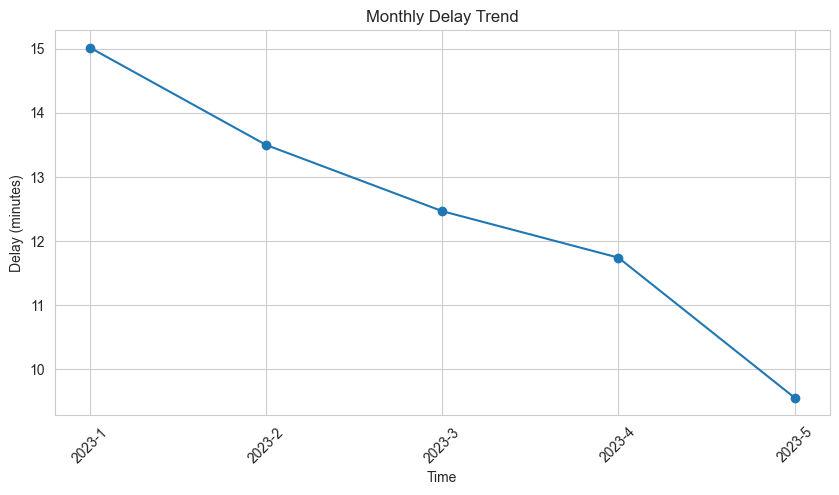

In [5]:
monthly_delay = df.groupby(["Year", "Month"])["ARR_DELAY"].mean().reset_index()

monthly_delay["Time"] = monthly_delay["Year"].astype(str) + "-" + monthly_delay["Month"].astype(str)

plt.figure(figsize=(10,5))
plt.plot(monthly_delay["Time"], monthly_delay["ARR_DELAY"], marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Delay Trend")
plt.xlabel("Time")
plt.ylabel("Delay (minutes)")
plt.show()

**c. Delay by Seasons**

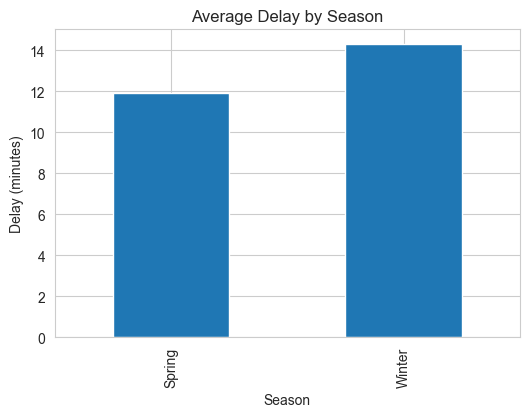

In [6]:
season_delay = df.groupby("Season")["ARR_DELAY"].mean()

plt.figure(figsize=(6,4))
season_delay.plot(kind="bar")
plt.title("Average Delay by Season")
plt.ylabel("Delay (minutes)")
plt.show()

**d. Best to Worst Routes**

In [14]:
route_stats = df.groupby("Route").agg(
    avg_delay=("ARR_DELAY", "mean"),
    delay_rate=("Is_Delayed", "mean"),
    flights=("Route", "count")
).reset_index()

fig = px.scatter(
    route_stats,
    x="flights",
    y="avg_delay",
    size="delay_rate",
    color="delay_rate",
    hover_name="Route",
    title="Route Delay Risk Analysis",
    labels={
        "flights": "Number of Flights",
        "avg_delay": "Average Delay",
        "delay_rate": "Delay Rate"
    }
)

fig.show()

**e. Airline vs Time**

In [13]:
heatmap_data = df.pivot_table(
    values="ARR_DELAY",
    index="OP_UNIQUE_CARRIER",
    columns="Month",
    aggfunc="mean"
)

fig = px.imshow(
    heatmap_data,
    text_auto=True,
    aspect="auto",
    title="Average Delay by Airline and Month",
    color_continuous_scale="RdYlGn_r"
)

fig.show()

**f. Delay Causes Breakdown**

In [11]:
cause_cols = [
    "CARRIER_DELAY",
    "WEATHER_DELAY",
    "NAS_DELAY",
    "SECURITY_DELAY",
    "LATE_AIRCRAFT_DELAY"
]

cause_avg = df[cause_cols].mean().reset_index()
cause_avg.columns = ["Cause", "Average Delay"]

fig = px.bar(
    cause_avg,
    x="Cause",
    y="Average Delay",
    color="Cause",
    title="Average Delay by Cause"
)

fig.show()

**g. Delay Distributions, Categories and Density**

In [12]:
fig = px.histogram(
    df,
    x="ARR_DELAY",
    color="Delay_Category",   # adds grouping
    nbins=60,
    marginal="box",           # adds boxplot on top
    opacity=0.7,
    title="Flight Delay Distribution by Category",
    hover_data=["OP_UNIQUE_CARRIER", "ORIGIN", "DEST"]
)

fig.update_layout(
    xaxis_title="Arrival Delay (minutes)",
    yaxis_title="Number of Flights",
    legend_title="Delay Category"
)

fig.show()